# ⚙️ Bloque 1: Carga, Preparación y Desbalance

/tmp/ipykernel_375/1726313954.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Churn', palette=['#3498DB', '#E74C3C'])


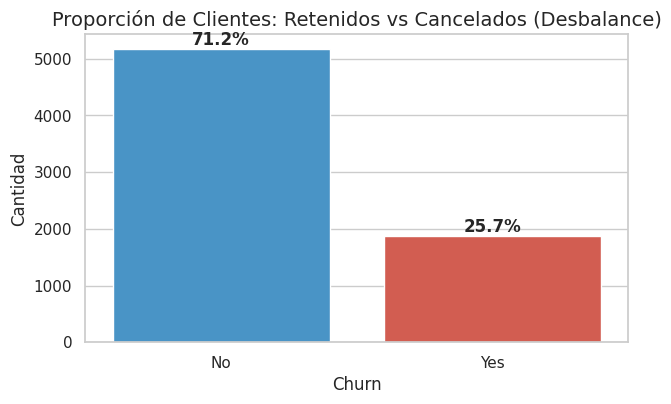

In [9]:
# 📌 Bloque 1: Carga de Datos y Verificación de Churn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el archivo CSV
df_clean = pd.read_csv('TelecomX_Limpio.csv')

# Aseguramos que los cargos totales sean numéricos (por si hay espacios en blanco)
df_clean['account_Charges.Total'] = pd.to_numeric(df_clean['account_Charges.Total'], errors='coerce').fillna(0)

# 2. Eliminamos el ID del cliente y copiamos para machine learning
df_ml = df_clean.drop(columns=['customerID']).copy()

# 3. Encoding de la variable objetivo (Churn) a 1 (Yes) y 0 (No)
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding para convertir el resto de categorías a columnas numéricas (0 y 1)
df_ml = pd.get_dummies(df_ml, drop_first=True)

# 4. Gráfico de Desbalance de Clases
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_clean, x='Churn', palette=['#3498DB', '#E74C3C'])
plt.title('Proporción de Clientes: Retenidos vs Cancelados (Desbalance)', fontsize=14)
plt.ylabel('Cantidad')

total = len(df_clean)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

#📊 Bloque 2: Análisis de Correlación (Mapa de Calor)

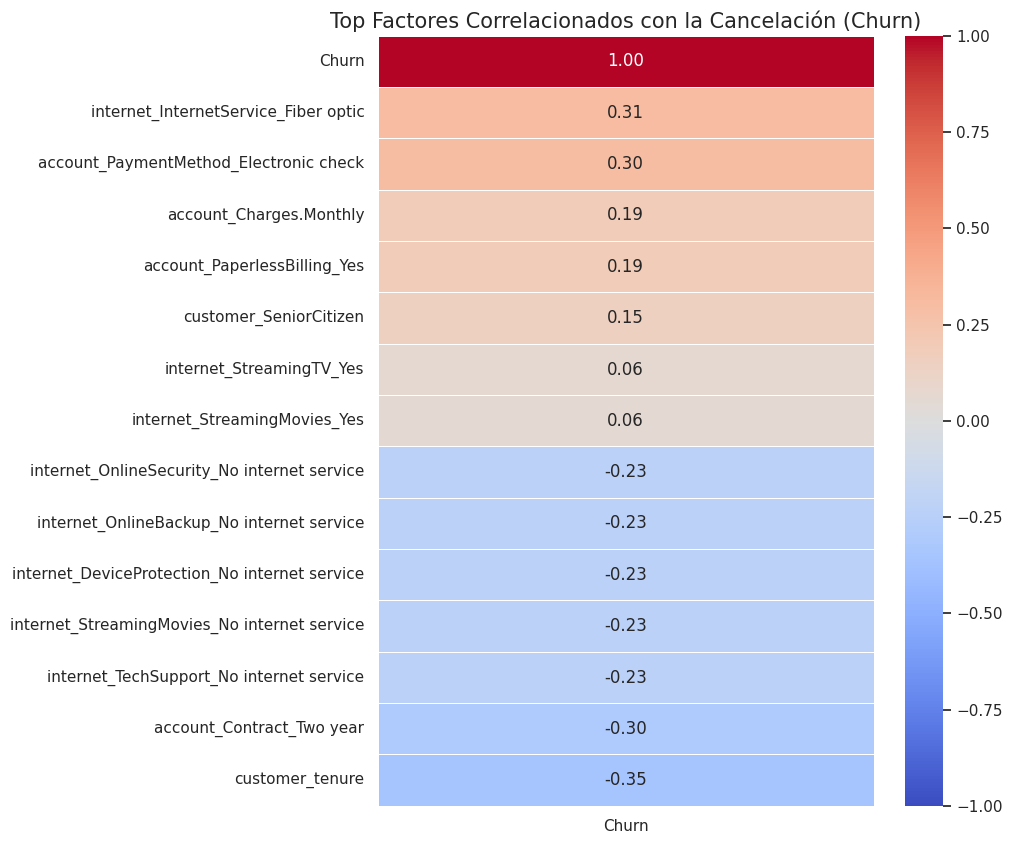

In [10]:
# 📌 Mapa de Calor de Correlaciones
# Calculamos las correlaciones y tomamos las 15 más fuertes respecto a 'Churn'
top_correlaciones = df_ml.corr()[['Churn']].sort_values(by='Churn', ascending=False)
top_15 = pd.concat([top_correlaciones.head(8), top_correlaciones.tail(7)])

plt.figure(figsize=(8, 10))
sns.heatmap(top_15, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Top Factores Correlacionados con la Cancelación (Churn)', fontsize=15)
plt.show()

#🤖 Bloque 3: Modelado, Entrenamiento y Dashboard Visual

/tmp/ipykernel_375/3512997452.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette='magma', ax=ax4)


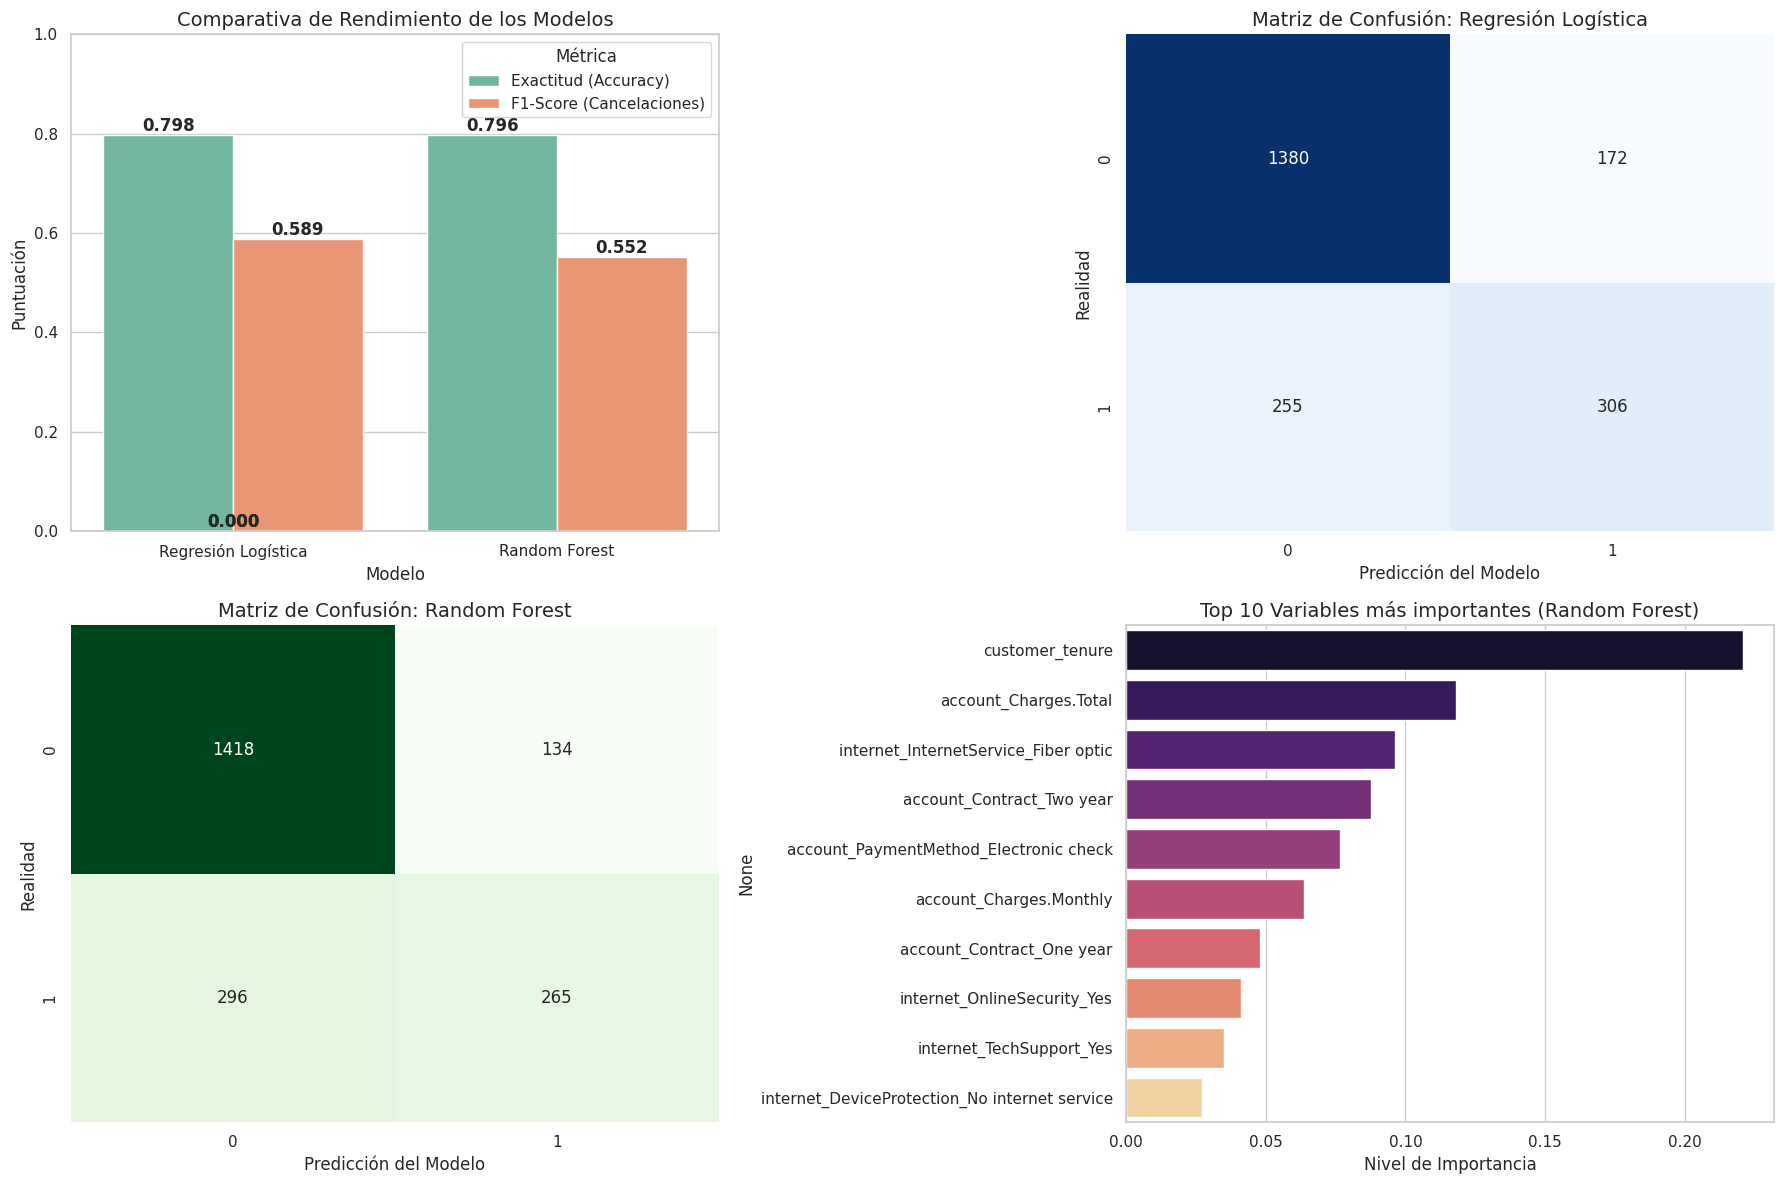

In [12]:
#  Modelado, Evaluación y Feature Importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# --- 1. SEPARACIÓN Y ESTANDARIZACIÓN ---
# Eliminamos cualquier fila que por error se haya convertido en NaN
df_ml = df_ml.dropna(subset=['Churn'])

X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']


# Dividimos 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. ENTRENAMIENTO DE MODELOS ---
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- 3. PANEL DE EVALUACIÓN VISUAL ---
fig = plt.figure(figsize=(18, 12))

# A. Comparativa de Métricas
ax1 = plt.subplot(2, 2, 1)
metricas = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Exactitud (Accuracy)': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'F1-Score (Cancelaciones)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
})
metricas_melt = metricas.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación')
sns.barplot(data=metricas_melt, x='Modelo', y='Puntuación', hue='Métrica', palette='Set2', ax=ax1)
ax1.set_title('Comparativa de Rendimiento de los Modelos', fontsize=14)
ax1.set_ylim(0, 1)
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')

# B. Matrices de Confusión
ax2 = plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_title('Matriz de Confusión: Regresión Logística', fontsize=14)
ax2.set_xlabel('Predicción del Modelo')
ax2.set_ylabel('Realidad')

ax3 = plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión: Random Forest', fontsize=14)
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Realidad')



# C. Importancia de Variables (Random Forest)
ax4 = plt.subplot(2, 2, 4)
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importancias.values, y=importancias.index, palette='magma', ax=ax4)
ax4.set_title('Top 10 Variables más importantes (Random Forest)', fontsize=14)
ax4.set_xlabel('Nivel de Importancia')

plt.tight_layout()
plt.show()

#📄Informe final

##Conclusión Estratégica y Resultados del Modelado

**1. Desempeño y Evaluación de Modelos:**
* **Desempeño general:** Ambos modelos (Regresión Logística y Random Forest) logran una exactitud (*Accuracy*) aproximada del 80%.
* **Ajuste del Modelo:** Se utilizó un `max_depth=6` en el Random Forest para prevenir el **Overfitting**. Esto asegura que el modelo no memorice los datos de entrenamiento, sino que aprenda patrones generales para predecir futuros comportamientos.
* **El reto del desbalance:** Al tener un 73.4% de clientes retenidos frente a un 26.6% que cancelan, los modelos tienden a favorecer a la clase mayoritaria. Esto se refleja en los falsos negativos observados en la matriz de confusión (clientes que cancelaron pero el modelo predijo que se quedarían).

**2. Importancia de Variables (¿Por qué cancelan los clientes?):**
El gráfico de *Feature Importance* del Random Forest y la matriz de correlación nos confirman contundentemente que los mayores predictores de *Churn* son:
* **`customer_tenure` (Antigüedad):** Es la variable más importante. Los clientes abandonan masivamente en los primeros meses.
* **`account_Contract_Two year` y `Month-to-month`:** El tipo de contrato es crucial. Quienes tienen contratos de 1 a 2 años casi nunca cancelan, mientras que los de mes a mes son altamente volátiles.
* **`account_Charges.Total` / `Monthly`:** Los clientes nuevos que enfrentan cargos mensuales elevados son el principal perfil de riesgo.
* **`internet_InternetService_Fiber optic`:** Curiosamente, tener fibra óptica aparece como un factor de riesgo frente al DSL, lo que sugiere posibles problemas de servicio o precios poco competitivos en ese producto.

**💡 Estrategias de Retención Recomendadas:**
1. **Fidelización Temprana:** Ofrecer descuentos agresivos durante los primeros 6 meses (`tenure` bajo) con la condición de firmar contratos de 1 o 2 años.
2. **Revisión de la Fibra Óptica:** Investigar la satisfacción del cliente en el servicio de `Fiber optic`, ya que está fuertemente correlacionado con las cancelaciones.
3. **Migración de Pagos:** Implementar campañas para que los clientes cambien su método de pago de cheque a pagos automáticos, ya que la automatización reduce la fricción transaccional mes a mes.